In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"cleaned_political_bias_data (1).csv")

In [3]:
df.head(3)

,News_ID,Title,News_Body,Stance,Label,issue,topic,roundup
0,0,north carolina house race carries unlikely han...,charlotte no the closely watched special us ho...,lean left,liberal,illegal ballot harvesting prompted re do of no...,voting rights and voter fraud,charlotte no the closely watched special us ho...
1,0,trump unloads on disloyal democratic house can...,high stakes were matched by some of president ...,lean right,conservative,illegal ballot harvesting prompted re do of no...,voting rights and voter fraud,high stakes were matched by some of president ...
2,0,illegal ballot harvesting caused a do over hou...,a us house special election in north carolinas...,center,center,illegal ballot harvesting prompted re do of no...,voting rights and voter fraud,a us house special election in north carolinas...


In [4]:
import pandas as pd
import re
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split

In [5]:
df = df.dropna(subset=['News_Body'])
print(f"\nShape after dropping nulls: {df.shape}")


Shape after dropping nulls: (9189, 8)


In [6]:
def clean(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+', '', text)       # remove URLs
    text = re.sub(r'[^a-z0-9\s]', ' ', text)       # keep only letters/numbers
    text = re.sub(r'\s+', ' ', text).strip()        # normalize whitespace
    return text

In [7]:
# Combining title + body as full input
df['text'] = df['Title'].apply(clean) + ' ' + df['News_Body'].apply(clean)
df['tokens'] = df['text'].apply(str.split)

In [9]:
# Deciding Time Steps
df['word_count'] = df['tokens'].apply(len)
print(f"Mean words : {df['word_count'].mean():.1f}")
print(f"Max words  : {df['word_count'].max()}")

Mean words : 81.1
Max words  : 172


In [10]:
MAX_LEN = 110
print(f"\n>>> Chosen MAX_LEN = {MAX_LEN}  (covers 92.3%)")


>>> Chosen MAX_LEN = 110  (covers 92.3%)


In [13]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.3 MB/s eta 0:00:00


In [14]:
import pandas as pd
import re
import numpy as np
import json
from collections import Counter
from sklearn.model_selection import train_test_split
import gensim.downloader as api

In [15]:
# Count every word in the corpus
all_words = [w for tokens in df['tokens'] for w in tokens]
freq      = Counter(all_words)

In [16]:
# Keep only words appearing at least 2 times
vocab_words = [w for w, c in freq.most_common() if c >= 2]

In [17]:
# 0 = PAD (padding), 1 = UNK (unknown/rare words)
word2idx = {'<PAD>': 0, '<UNK>': 1}
for w in vocab_words:
    word2idx[w] = len(word2idx)

In [18]:
idx2word   = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)

In [19]:
print(f"Total unique words   : {len(freq):,}")
print(f"Vocab size (freq>=2) : {VOCAB_SIZE:,}")
print(f"Rare words dropped   : {len(freq) - VOCAB_SIZE + 2:,}")


Total unique words   : 19,752
Vocab size (freq>=2) : 14,015
Rare words dropped   : 5,739


In [20]:
EMBED_DIM = 100   # GloVe dimension

# Download GloVe
print("Loading GloVe vectors...")
glove = api.load('glove-wiki-gigaword-100')
print(f"GloVe loaded. Total vectors: {len(glove):,}")

Loading GloVe vectors...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded. Total vectors: 400,000


In [21]:
# Build matrix — shape (VOCAB_SIZE, EMBED_DIM)
# Row 0 = PAD → all zeros
# Row 1 = UNK → mean of all GloVe vectors
# Row i = GloVe vector for word i  (or UNK if not found)
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)

In [22]:
unk_vector            = np.mean(glove.vectors, axis=0)
embedding_matrix[1]   = unk_vector    # UNK token


In [23]:
found = 0
not_found = 0

for word, idx in word2idx.items():
    if word in ('<PAD>', '<UNK>'):
        continue
    if word in glove:
        embedding_matrix[idx] = glove[word]
        found += 1
    else:
        embedding_matrix[idx] = unk_vector
        not_found += 1

print(f"Words found in GloVe    : {found:,}  ({found/VOCAB_SIZE*100:.1f}%)")
print(f"Words not in GloVe      : {not_found:,}  ({not_found/VOCAB_SIZE*100:.1f}%)")
print(f"Embedding matrix shape  : {embedding_matrix.shape}")


Words found in GloVe    : 13,996  (99.9%)
Words not in GloVe      : 17  (0.1%)
Embedding matrix shape  : (14015, 100)


In [24]:
MAX_LEN = 110    # covers 92.3% of articles

def encode_and_pad(tokens, word2idx, max_len):
    ids  = [word2idx.get(w, 1) for w in tokens]   # unknown → 1
    ids  = ids[:max_len]                            # truncate
    ids += [0] * (max_len - len(ids))              # pad with 0
    return ids

X = np.array(
    [encode_and_pad(t, word2idx, MAX_LEN) for t in df['tokens']],
    dtype=np.int32
)

label_map = {'liberal': 0, 'center': 1, 'conservative': 2}
y = np.array([label_map[l] for l in df['Label']], dtype=np.int32)

print(f"X shape : {X.shape}    (samples x timesteps)")
print(f"y shape : {y.shape}")
print(f"Classes : 0=liberal | 1=center | 2=conservative")
print(f"Balance : {np.bincount(y)}")

X shape : (9189, 110)    (samples x timesteps)
y shape : (9189,)
Classes : 0=liberal | 1=center | 2=conservative
Balance : [3065 3062 3062]


In [25]:
# Train Test Validation Split

In [26]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y,
    test_size   = 0.30,
    random_state= 42,
    stratify    = y       # keeps class balance in every split
)

In [27]:
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size   = 0.50,
    random_state= 42,
    stratify    = y_tmp
)

print(f"Train : {X_train.shape}   labels = {np.bincount(y_train)}")
print(f"Val   : {X_val.shape}    labels = {np.bincount(y_val)}")
print(f"Test  : {X_test.shape}   labels = {np.bincount(y_test)}")


Train : (6432, 110)   labels = [2146 2143 2143]
Val   : (1378, 110)    labels = [460 459 459]
Test  : (1379, 110)   labels = [459 460 460]


In [28]:
# Model Building

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    Dense, Dropout, Layer
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
import tensorflow.keras.backend as K

In [30]:
VOCAB_SIZE = len(word2idx)     # 14,015
EMBED_DIM  = 100               # GloVe dimension
MAX_LEN    = 110               # timesteps
NUM_CLASSES= 3                 # liberal, center, conservative

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Embedding matrix : {embedding_matrix.shape}")

X_train : (6432, 110)
X_val   : (1378, 110)
X_test  : (1379, 110)
Embedding matrix : (14015, 100)


In [68]:
class AttentionLayer(Layer):
    """
    Bahdanau-style additive attention.
    Learns which timesteps (words) matter most for classification.
    Input  : (batch, timesteps, features)
    Output : (batch, features)  — weighted sum over timesteps
    """
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name    = 'attention_weight',
            shape   = (input_shape[-1], 1),
            initializer = 'glorot_uniform',
            trainable   = True
        )
        self.b = self.add_weight(
            name    = 'attention_bias',
            shape   = (input_shape[1], 1),
            initializer = 'zeros',
            trainable   = True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        # Score each timestep
        score  = K.tanh(K.dot(x, self.W) + self.b)   # (batch, timesteps, 1)
        # Normalise scores → attention weights
        alpha  = K.softmax(score, axis=1)             # (batch, timesteps, 1)
        # Weighted sum of LSTM outputs
        context = x * alpha                           # (batch, timesteps, features)
        context = K.sum(context, axis=1)              # (batch, features)
        return context

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])


In [69]:
from tensorflow.keras.layers import SpatialDropout1D, GlobalAveragePooling1D, Concatenate
from tensorflow.keras.optimizers.schedules import ExponentialDecay

def build_model(vocab_size, embed_dim, max_len,
                embedding_matrix, num_classes,
                lstm_units  = 128,
                dense_units = 128,
                dropout1    = 0.5,
                dropout2    = 0.3,
                lr          = 0.001):

    # ── Input ──────────────────────────────────────────────
    inputs = Input(shape=(max_len,), name='input')

    # ── Embedding (GloVe, trainable) ───────────────────────
    x = Embedding(
        input_dim    = vocab_size,
        output_dim   = embed_dim,
        weights      = [embedding_matrix],   # pre-trained GloVe
        input_length = max_len,
        trainable    = True,                 # fine-tune during training
        name         = 'glove_embedding'
    )(inputs)

    # ── Bidirectional LSTM ─────────────────────────────────
    x = Bidirectional(
        LSTM(lstm_units,
             return_sequences = True,        # keep all timestep outputs
             dropout          = 0.2,         # input dropout
             recurrent_dropout= 0.2),        # recurrent dropout
        name = 'bi_lstm'
    )(x)

    # ── Attention ──────────────────────────────────────────
    x = AttentionLayer(name='attention')(x)  # (batch, 2*lstm_units)

    # ── Dense Block ────────────────────────────────────────
    x = Dropout(dropout1, name='dropout_1')(x)
    x = Dense(dense_units, activation='relu', name='dense_1')(x)
    x = Dropout(dropout2, name='dropout_2')(x)

    # ── Output ─────────────────────────────────────────────
    outputs = Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer = Adam(learning_rate=lr),
        loss      = 'sparse_categorical_crossentropy',
        metrics   = ['accuracy']
    )
    return model

In [70]:
model = build_model(
    vocab_size       = VOCAB_SIZE,
    embed_dim        = EMBED_DIM,
    max_len          = MAX_LEN,
    embedding_matrix = embedding_matrix,
    num_classes      = NUM_CLASSES,
    lstm_units       = 128,
    dense_units      = 128,
    dropout1         = 0.5,
    dropout2         = 0.3,
    lr               = 0.001
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 110)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 110, 100)       │     1,401,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm (Bidirectional)         │ (None, 110, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 256)            │           366 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,669,645 (6.37 MB)

 Trainable params: 1,669,645 (6.37 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
callbacks = [

    # Stop training if val_loss doesn't improve for 4 epochs
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 4,
        restore_best_weights = True,
        verbose              = 1
    ),

    # Halve learning rate if val_loss plateaus for 2 epochs
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 2,
        min_lr   = 1e-6,
        verbose  = 1
    ),

    # Save best model weights in current session folder
    ModelCheckpoint(
        filepath       = 'best_model.keras',
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    )
]

In [73]:
# CELL 6 (BALANCED) — Train
# ============================================================
history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 20,
    batch_size      = 64,
    callbacks       = callbacks,
    verbose         = 1
)

print("\nTraining complete.")



Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.3464 - loss: 1.1132
Epoch 1: val_accuracy improved from None to 0.33454, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 89s 773ms/step - accuracy: 0.3378 - loss: 1.1091 - val_accuracy: 0.3345 - val_loss: 1.1003 - learning_rate: 0.0010
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.3350 - loss: 1.1043
Epoch 2: val_accuracy improved from 0.33454 to 0.33745, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 77s 725ms/step - accuracy: 0.3347 - loss: 1.1025 - val_accuracy: 0.3374 - val_loss: 1.0986 - learning_rate: 0.0010
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.3418 - loss: 1.1014
Epoch 3: val_accuracy improved from 0.33745 to 0.36284, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━

In [74]:
# ============================================================
# CELL 7 — Evaluate on Test Set
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [75]:
# Load best saved weights
model = tf.keras.models.load_model(
    'best_model.keras',
    custom_objects = {'AttentionLayer': AttentionLayer}
)

In [76]:
# Predict
y_pred    = np.argmax(model.predict(X_test), axis=1)


44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step


In [81]:
# Accuracy & Loss
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")



Test Accuracy : 38.29%
Test Loss     : 1.2435


In [78]:
# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names = ['liberal', 'center', 'conservative']
))


Classification Report:
              precision    recall  f1-score   support

     liberal       0.38      0.44      0.41       459
      center       0.38      0.31      0.34       460
conservative       0.38      0.40      0.39       460

    accuracy                           0.38      1379
   macro avg       0.38      0.38      0.38      1379
weighted avg       0.38      0.38      0.38      1379



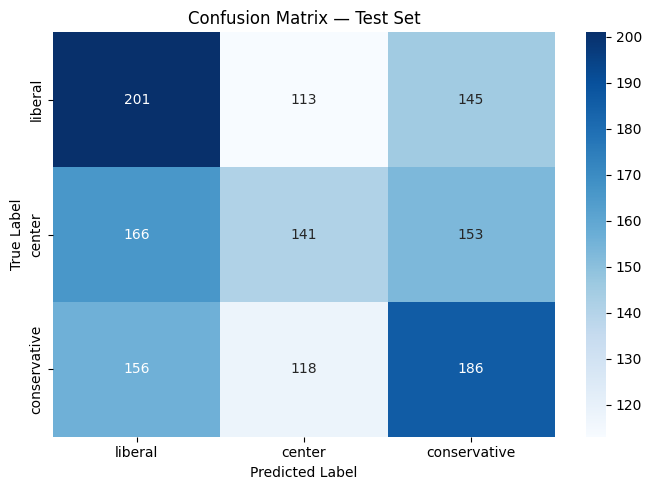

In [79]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels = ['liberal', 'center', 'conservative'],
    yticklabels = ['liberal', 'center', 'conservative']
)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


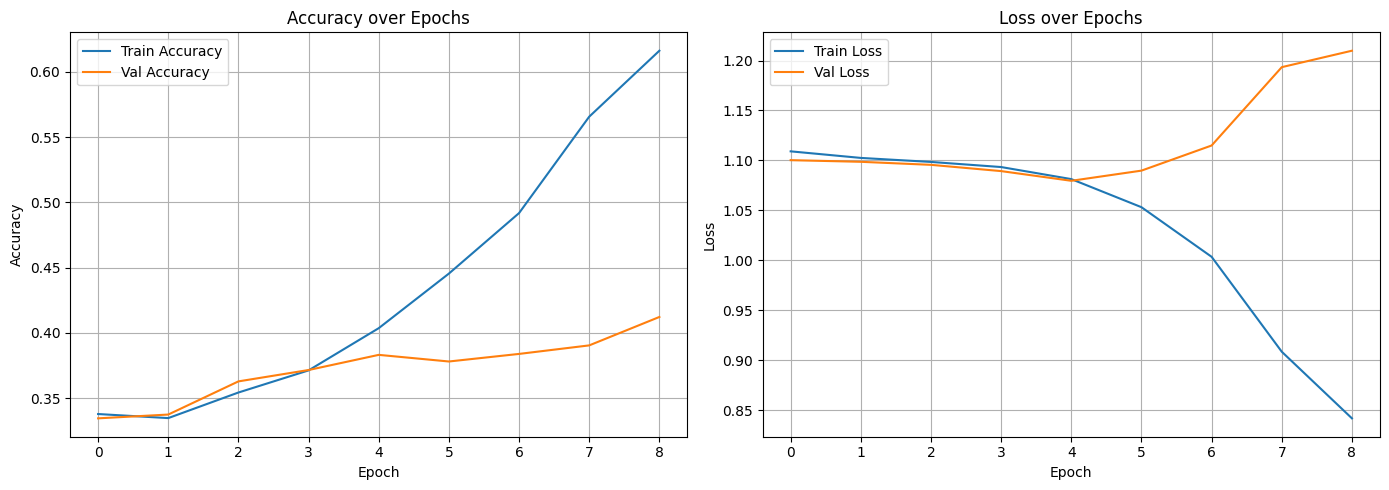

In [80]:
# CELL 8 — Plot Training History
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()